<a href="https://colab.research.google.com/github/rasyadtanzilur/pengolahancitra/blob/main/Tugas_Besar_Rasyad%20Tanzilur%20Rahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install ultralytics opencv-python pandas numpy


In [5]:
import cv2
import pandas as pd
from ultralytics import YOLO
from tracker import *

# Load model YOLOv8
model = YOLO('yolov8s.pt')

# Buka video input
cap = cv2.VideoCapture('veh2.mp4')

# Baca daftar class
with open("coco.txt", "r") as f:
    class_list = f.read().split("\n")

# Tracker dan konfigurasi garis (jika nanti dipakai)
tracker = Tracker()
cy1 = 322
cy2 = 368
offset = 6

# Ambil ukuran frame
ret, frame = cap.read()
if not ret:
    raise Exception("Gagal membaca video.")

frame = cv2.resize(frame, (1020, 500))
height, width, _ = frame.shape

# Siapkan output writer
out = cv2.VideoWriter("output.mp4", cv2.VideoWriter_fourcc(*'mp4v'), 30, (width, height))

# Reset ke awal
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    count += 1
    if count % 3 != 0:
        continue

    frame = cv2.resize(frame, (1020, 500))
    results = model.predict(frame)
    a = results[0].boxes.data
    px = pd.DataFrame(a).astype("float")

    list = []
    for index, row in px.iterrows():
        x1, y1, x2, y2 = int(row[0]), int(row[1]), int(row[2]), int(row[3])
        d = int(row[5])
        c = class_list[d]
        if 'car' in c:
            list.append([x1, y1, x2, y2])

    bbox_id = tracker.update(list)

    for bbox in bbox_id:
        x3, y3, x4, y4, id = bbox
        cx = int((x3 + x4) / 2)
        cy = int((y3 + y4) / 2)
        cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)
        cv2.putText(frame, str(id), (cx, cy), cv2.FONT_HERSHEY_COMPLEX, 0.8, (0, 255, 255), 2)

    # Simpan ke output file
    out.write(frame)

# Bersihkan
cap.release()
out.release()


Streaming output truncated to the last 5000 lines.
0: 320x640 1 person, 2 cars, 1 stop sign, 322.6ms
Speed: 3.1ms preprocess, 322.6ms inference, 1.7ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 1 stop sign, 451.9ms
Speed: 8.4ms preprocess, 451.9ms inference, 1.7ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 1 stop sign, 512.0ms
Speed: 5.3ms preprocess, 512.0ms inference, 1.7ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 1 stop sign, 515.7ms
Speed: 5.8ms preprocess, 515.7ms inference, 1.7ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 488.0ms
Speed: 3.3ms preprocess, 488.0ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 394.2ms
Speed: 4.0ms preprocess, 394.2ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 300.4ms
Speed: 2.7ms preprocess, 300.4ms inference, 

In [6]:
import cv2
import pandas as pd
import numpy as np
from ultralytics import YOLO
from tracker import*
import time
from math import dist

model = YOLO('yolov8s.pt')

cap = cv2.VideoCapture('veh2.mp4')

my_file = open("coco.txt", "r")
data = my_file.read()
class_list = data.split("\n")

count = 0
tracker = Tracker()

cy1 = 322
cy2 = 368
offset = 6

vh_down = {}
counter = []

vh_up = {}
counter1 = []

# 🟢 Simpan ke video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('output_speed.mp4', fourcc, 30.0, (1020, 500))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    count += 1
    if count % 3 != 0:
        continue
    frame = cv2.resize(frame, (1020, 500))

    results = model.predict(frame)
    a = results[0].boxes.data
    px = pd.DataFrame(a).astype("float")

    list = []
    for index, row in px.iterrows():
        x1, y1, x2, y2, _, d = map(int, row[:6])
        c = class_list[d]
        if 'car' in c:
            list.append([x1, y1, x2, y2])

    bbox_id = tracker.update(list)
    for bbox in bbox_id:
        x3, y3, x4, y4, id = bbox
        cx = (x3 + x4) // 2
        cy = (y3 + y4) // 2
        cv2.rectangle(frame, (x3, y3), (x4, y4), (0, 0, 255), 2)

        # Going down
        if cy1 - offset < cy < cy1 + offset:
            vh_down[id] = time.time()
        if id in vh_down and cy2 - offset < cy < cy2 + offset:
            elapsed_time = time.time() - vh_down[id]
            if id not in counter:
                counter.append(id)
                distance = 10  # meters
                speed_kh = (distance / elapsed_time) * 3.6
                cv2.putText(frame, str(int(speed_kh)) + ' Km/h', (x4, y4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

        # Going up
        if cy2 - offset < cy < cy2 + offset:
            vh_up[id] = time.time()
        if id in vh_up and cy1 - offset < cy < cy1 + offset:
            elapsed1_time = time.time() - vh_up[id]
            if id not in counter1:
                counter1.append(id)
                distance1 = 10  # meters
                speed_kh1 = (distance1 / elapsed1_time) * 3.6
                cv2.putText(frame, str(int(speed_kh1)) + ' Km/h', (x4, y4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

    # Tambah garis dan info
    cv2.line(frame, (274, cy1), (814, cy1), (255, 255, 255), 1)
    cv2.putText(frame, 'L1', (277, 320), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
    cv2.line(frame, (177, cy2), (927, cy2), (255, 255, 255), 1)
    cv2.putText(frame, 'L2', (182, 367), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

    cv2.putText(frame, f'Going Down: {len(counter)}', (60, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
    cv2.putText(frame, f'Going Up: {len(counter1)}', (60, 130), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

    out.write(frame)  # 🟢 Simpan frame ke file video

cap.release()
out.release()


Streaming output truncated to the last 5000 lines.
0: 320x640 1 person, 2 cars, 1 stop sign, 281.2ms
Speed: 3.3ms preprocess, 281.2ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 1 stop sign, 311.1ms
Speed: 2.9ms preprocess, 311.1ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 1 stop sign, 304.9ms
Speed: 3.2ms preprocess, 304.9ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 1 stop sign, 273.3ms
Speed: 2.9ms preprocess, 273.3ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 296.0ms
Speed: 2.9ms preprocess, 296.0ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 296.1ms
Speed: 4.0ms preprocess, 296.1ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 1 person, 2 cars, 273.8ms
Speed: 3.4ms preprocess, 273.8ms inference, 

In [9]:
import os

print("Apakah file ada:", os.path.exists("output_speed.mp4"))
print("Ukuran file (byte):", os.path.getsize("output_speed.mp4") if os.path.exists("output_speed.mp4") else "tidak ada")


Apakah file ada: True
Ukuran file (byte): 33187224


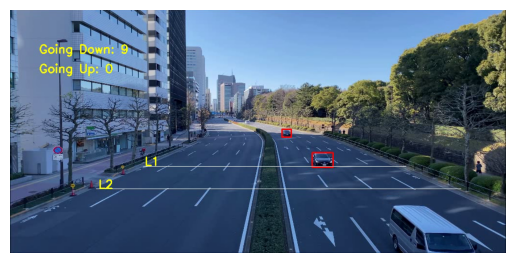

In [ ]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# Buka video hasil deteksi
cap = cv2.VideoCapture('output_speed.mp4')

# Tampilkan hanya 1 frame setiap x frame (biar ringan)
frame_interval = 3
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % frame_interval != 0:
        continue

    # Convert BGR ke RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Tampilkan
    plt.imshow(frame)
    plt.axis('off')
    display(plt.gcf())
    clear_output(wait=True)
    time.sleep(0.05)  # jeda antar frame, makin kecil makin cepat

cap.release()
